
# Breast Cancer Wisconsin: EDA + K-Means Clustering

This notebook includes:

- Exploratory Data Analysis (EDA)
- Data Cleaning
- Feature Standardization
- K-Means Clustering from Scratch using NumPy
- Elbow Method
- Final Clustering Analysis


In [50]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# dataset exploration

In [51]:
# load Dataset
df = pd.read_csv("data.csv", )
print(f"shape: {df.shape}")


shape: (569, 33)


In [52]:
df.head(10)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN
5,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,...,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440,NaN
6,844359,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,...,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368,NaN
7,84458202,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,...,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510,NaN
8,844981,M,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,...,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720,NaN
9,84501001,M,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,...,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750,NaN


In [53]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [54]:
#dropped unecessary Unnamed: 32 column
df.drop(columns=["Unnamed: 32", "id"], inplace=True)

In [55]:
# dataset balancing
print(df["diagnosis"].value_counts())

diagnosis
B    357
M    212
Name: count, dtype: int64


### Dataset is somewhat balanced, no need for custom balancing, only removal of unnecessary filler Unnamed: 32 column and ID column

# Feature Statistics

In [56]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])
# define counts and feats before plotting
counts = df['diagnosis'].value_counts()
feats = df.drop(columns=['diagnosis']) 
target_corr = df.corr()['diagnosis'].drop('diagnosis').sort_values(ascending=False)

correlations = df.corr()['diagnosis'].sort_values(ascending=False)

# display the correlations
print(correlations)

diagnosis                  1.000000
concave points_worst       0.793566
perimeter_worst            0.782914
concave points_mean        0.776614
radius_worst               0.776454
perimeter_mean             0.742636
area_worst                 0.733825
radius_mean                0.730029
area_mean                  0.708984
concavity_mean             0.696360
concavity_worst            0.659610
compactness_mean           0.596534
compactness_worst          0.590998
radius_se                  0.567134
perimeter_se               0.556141
area_se                    0.548236
texture_worst              0.456903
smoothness_worst           0.421465
symmetry_worst             0.416294
texture_mean               0.415185
concave points_se          0.408042
smoothness_mean            0.358560
symmetry_mean              0.330499
fractal_dimension_worst    0.323872
compactness_se             0.292999
concavity_se               0.253730
fractal_dimension_se       0.077972
symmetry_se               -0

C:\Users\Gebriel\AppData\Local\Temp\ipykernel_296\622808825.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


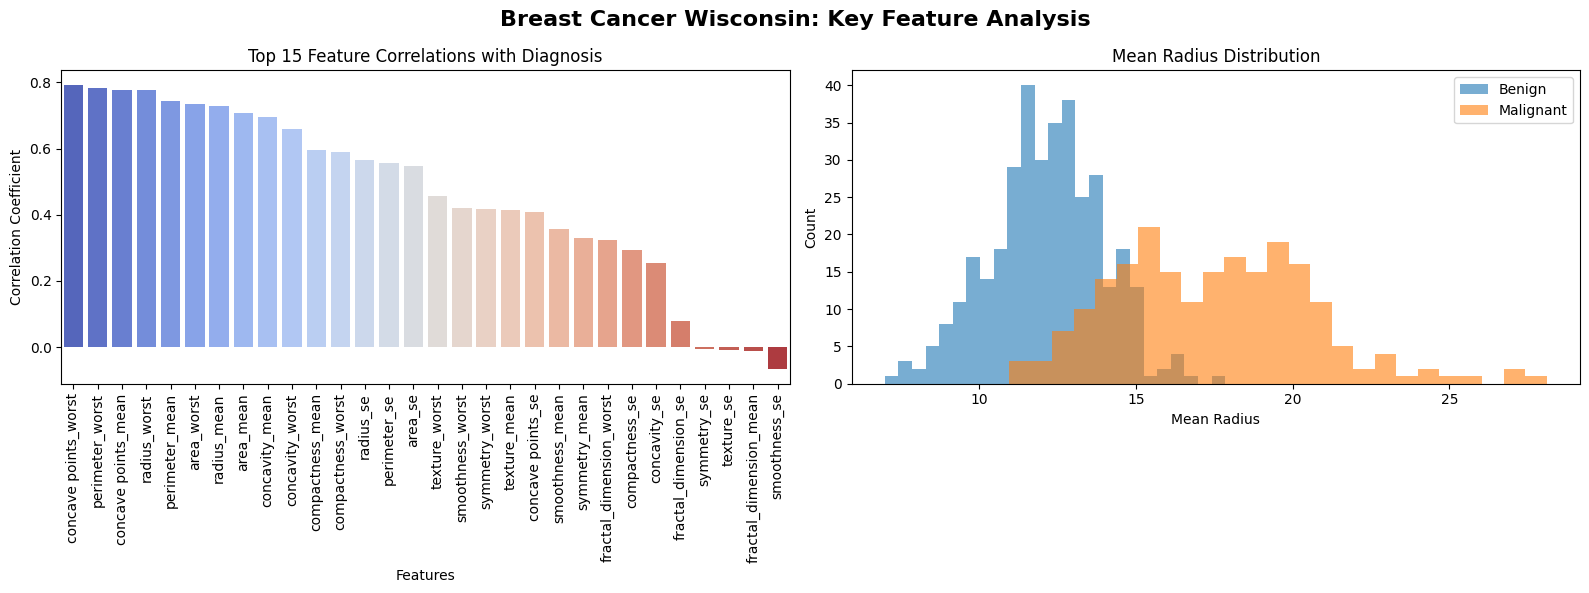

In [57]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6)) 

fig.suptitle(
    "Breast Cancer Wisconsin: Key Feature Analysis",
    fontsize=16,
    fontweight="bold"
)
ax = axes[0]

sns.barplot(
    x=target_corr.index,
    y=target_corr.values,
    ax=ax,
    palette="coolwarm"
)

ax.set_title("Top 15 Feature Correlations with Diagnosis")
ax.set_ylabel("Correlation Coefficient")
ax.set_xlabel("Features")

# Rotate the x-axis labels so they don't overlap
ax.tick_params(axis='x', rotation=90)

ax = axes[1]

ax.hist(
    df[df["diagnosis"] == 0]["radius_mean"],
    bins=25,
    alpha=0.6,
    label="Benign"
)

ax.hist(
    df[df["diagnosis"] == 1]["radius_mean"],
    bins=25,
    alpha=0.6,
    label="Malignant"
)

ax.set_title("Mean Radius Distribution")
ax.set_xlabel("Mean Radius")
ax.set_ylabel("Count")
ax.legend()

plt.tight_layout()
plt.savefig("refined_eda_plots.png", dpi=150)
plt.show()

# Feature Engineering

In [58]:
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

In [59]:
#standardize the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

print("Data standardized successfully with StandardScaler.")

Data standardized successfully with StandardScaler.


In [60]:
# Create a combined severity index
df['severity_index'] = df['area_worst'] * df['concave points_worst']

# Drop features with practically zero correlation
df = df.drop(columns=['symmetry_se', 'texture_se', 'fractal_dimension_mean', 'smoothness_se', 'area_worst', 'concave points_worst'])

# K-Means Functions (Experiment 1)

In [61]:
def init_centroids(X, k, seed=42):
    # pick k random data points to act as initial cluster centers
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(X), size=k, replace=False)
    return X[idx].copy()


def assign_clusters(X, centroids):
    # compute euclidean distances using 3d array broadcasting
    diffs = X[:, np.newaxis, :] - centroids[np.newaxis, :, :]
    dists = np.sqrt((diffs ** 2).sum(axis=2))
    
    # assign each point to the closest centroid
    return np.argmin(dists, axis=1)


def update_centroids(X, labels, k):
    new_c = np.zeros((k, X.shape[1]))

    for cid in range(k):
        members = X[labels == cid]

        # if a cluster is empty, reassign it to a random data point
        if len(members) == 0:
            new_c[cid] = X[np.random.randint(len(X))]
        # otherwise, move the centroid to the mean of its assigned points
        else:
            new_c[cid] = members.mean(axis=0)

    return new_c


def compute_sse(X, labels, centroids):
    # calculate the sum of squared distances for all points to their centroids
    total = 0.0
    for cid, c in enumerate(centroids):
        members = X[labels == cid]
        total += ((members - c) ** 2).sum()

    return total


def kmeans(X, k, max_iters=300, tol=1e-4, seed=42):
    centroids = init_centroids(X, k, seed)

    for it in range(max_iters):
        # step 1: assign points
        labels = assign_clusters(X, centroids)
        
        # step 2: update centers
        new_centroids = update_centroids(X, labels, k)

        # step 3: check how far the centers moved
        shift = np.sqrt(
            ((new_centroids - centroids) ** 2).sum(axis=1)
        ).max()
        centroids = new_centroids

        # stop early if centers stopped moving
        if shift < tol:
            break

    # compute final error metric
    sse = compute_sse(X, labels, centroids)

    return labels, centroids, sse, it + 1

# Elbow Method

In [62]:

k_range = range(1, 11)

sse_list = []

print(f"{'k':>3} | {'SSE':>12} | {'Iterations':>10}")
print("-" * 35)

for k in k_range:

    _, _, sse, iters = kmeans(X, k)

    sse_list.append(sse)

    print(f"{k:>3} | {sse:>12,.2f} | {iters:>10}")


  k |          SSE | Iterations
-----------------------------------
  1 |    17,070.00 |          2
  2 |    11,595.53 |          7
  3 |    10,065.44 |         24
  4 |     9,334.91 |         25
  5 |     8,651.05 |         20
  6 |     7,973.59 |         33
  7 |     7,902.97 |         17
  8 |     7,243.87 |         31
  9 |     7,109.23 |         11
 10 |     6,928.72 |         12


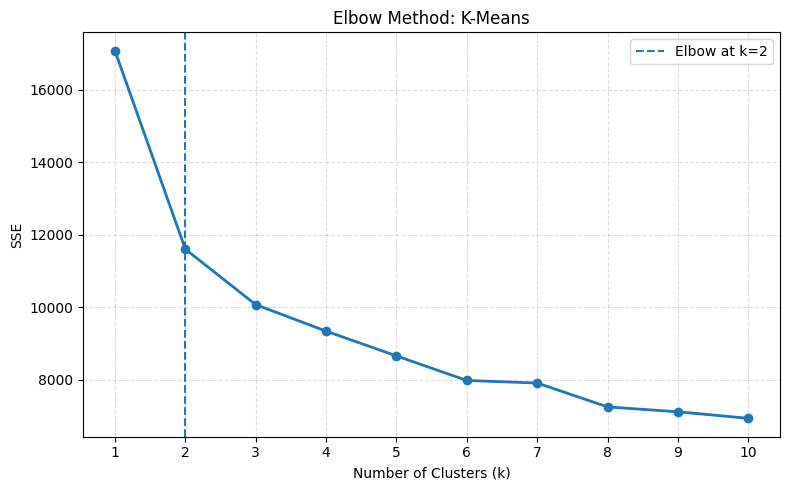

In [63]:

# Elbow Plot

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    list(k_range),
    sse_list,
    marker="o",
    linewidth=2
)

ax.axvline(
    x=2,
    linestyle="--",
    linewidth=1.5,
    label="Elbow at k=2"
)

ax.set_title("Elbow Method: K-Means")

ax.set_xlabel("Number of Clusters (k)")
ax.set_ylabel("SSE")

ax.set_xticks(list(k_range))

ax.grid(True, linestyle="--", alpha=0.4)

ax.legend()

plt.tight_layout()

plt.savefig("elbow_experiment1.png", dpi=150)

plt.show()


In [64]:

# final Clustering
best_k = 2

labels, centroids, final_sse, iters = kmeans(X, best_k)

print(f"SSE        : {final_sse:,.4f}")
print(f"Iterations : {iters}")
print()

for cid in range(best_k):

    mask = labels == cid

    m = (y[mask] == 1).sum()
    b = (y[mask] == 0).sum()

    print(
        f"Cluster {cid} → {mask.sum()} points | M={m} B={b}"
    )


SSE        : 11,595.5266
Iterations : 7

Cluster 0 → 375 points | M=36 B=339
Cluster 1 → 194 points | M=176 B=18



# Conclusions

## Key Findings

1. The dataset naturally separates into two groups:
   - Benign (B)
   - Malignant (M)

2. The `id` column was removed because it is only an identifier.

3. The `Unnamed: 32` column contained only missing values.

4. Standardization was necessary because K-Means is distance-based.

5. The Elbow Method clearly suggested `k = 2`.

6. K-Means successfully grouped many samples correctly without using labels during training.

7. The dataset contains strong clustering structure and meaningful feature relationships.


# PCA Funcs (Experiment 2)

In [65]:
def implement_pca(X, n_components):
    # calculate covariance matrix
    cov_matrix = np.cov(X, rowvar=False)
    
    # compute eigenvalues and eigenvectors
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
    
    # sort in descending order
    sorted_indices = np.argsort(eigenvalues)[::-1]
    sorted_eigenvalues = eigenvalues[sorted_indices]
    sorted_eigenvectors = eigenvectors[:, sorted_indices]
    
    # select top components
    top_eigenvectors = sorted_eigenvectors[:, :n_components]
    
    # transform data
    X_reduced = np.dot(X, top_eigenvectors)
    
    return X_reduced, sorted_eigenvalues, top_eigenvectors

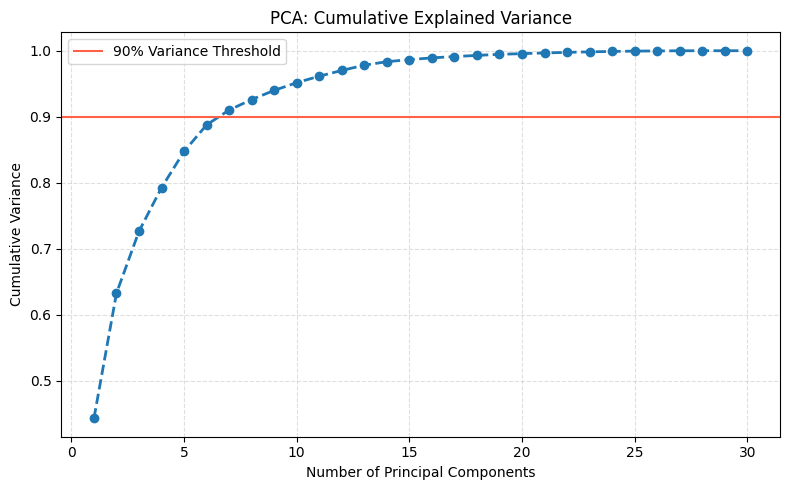

Optimal number of components for 90% variance: 7


In [66]:
# run pca with all features (30) to see total variance
_, eigenvalues, _ = implement_pca(X, n_components=X.shape[1])

# calculate explained variance ratio
total_variance = np.sum(eigenvalues)
explained_variance_ratio = eigenvalues / total_variance
cumulative_variance = np.cumsum(explained_variance_ratio)

# plot cumulative explained variance
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    range(1, len(cumulative_variance) + 1), 
    cumulative_variance, 
    marker='o', 
    linestyle='--', 
    linewidth=2
)

# add a threshold line at 90% variance
ax.axhline(y=0.90, color='tomato', linestyle='-', label='90% Variance Threshold')

ax.set_title("PCA: Cumulative Explained Variance")
ax.set_xlabel("Number of Principal Components")
ax.set_ylabel("Cumulative Variance")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("pca_variance.png", dpi=150)
plt.show()

optimal_n = np.argmax(cumulative_variance >= 0.90) + 1
print(f"Optimal number of components for 90% variance: {optimal_n}")

In [67]:
# reduce the dataset using our custom PCA function
X_pca, _, _ = implement_pca(X, n_components=optimal_n)

sse_list_pca = []

print(f"\n{'k':>3} | {'PCA SSE':>12} | {'Iterations':>10}")
print("-" * 35)

for k in k_range:
    # Run K-Means on the REDUCED dataset
    _, _, sse, iters = kmeans(X_pca, k)
    sse_list_pca.append(sse)
    print(f"{k:>3} | {sse:>12,.2f} | {iters:>10}")


  k |      PCA SSE | Iterations
-----------------------------------
  1 |    15,535.33 |          2
  2 |    10,063.10 |          7
  3 |     8,537.90 |         25
  4 |     7,812.31 |         17
  5 |     7,045.90 |         35
  6 |     6,633.46 |         25
  7 |     6,186.71 |         57
  8 |     5,764.89 |         24
  9 |     5,631.06 |         13
 10 |     5,431.82 |         17


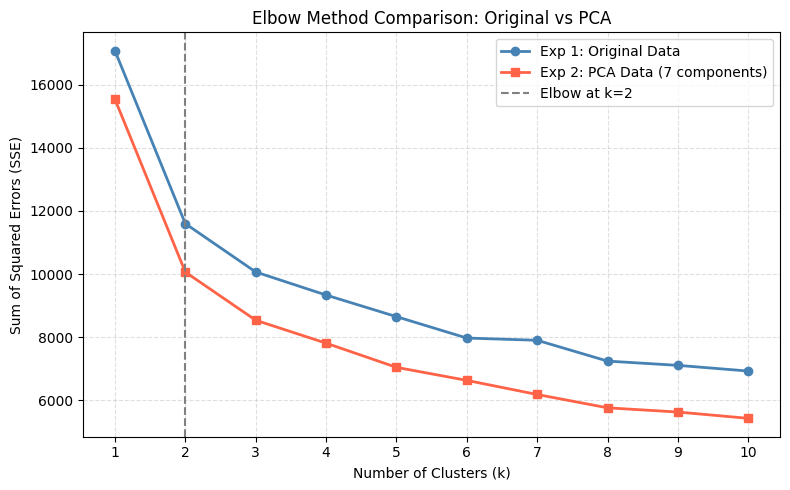

In [68]:
fig, ax = plt.subplots(figsize=(8, 5))

# plot experiment 1
ax.plot(list(k_range), sse_list, marker="o", linewidth=2, label="Exp 1: Original Data", color="steelblue")

# plot experiment 2
ax.plot(list(k_range), sse_list_pca, marker="s", linewidth=2, label=f"Exp 2: PCA Data ({optimal_n} components)", color="tomato")

# add elbow marker
ax.axvline(x=2, linestyle="--", linewidth=1.5, color="gray", label="Elbow at k=2")

ax.set_title("Elbow Method Comparison: Original vs PCA")
ax.set_xlabel("Number of Clusters (k)")
ax.set_ylabel("Sum of Squared Errors (SSE)")
ax.set_xticks(list(k_range))
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend()

plt.tight_layout()
plt.savefig("elbow_comparison.png", dpi=150)
plt.show()

Clustering Match Accuracy vs True Labels: 90.51%


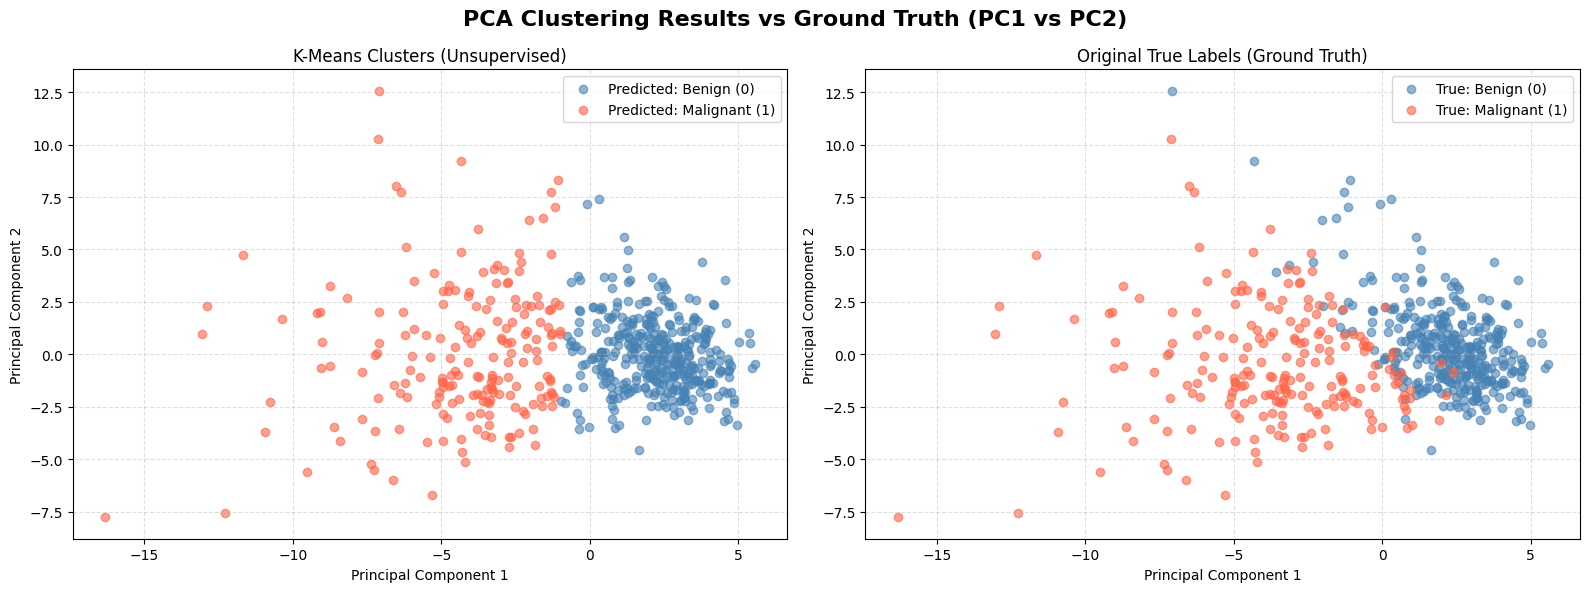

In [69]:
# run K-Means on PCA data with the best k (k=2)
best_k = 2
pca_labels, pca_centroids, _, _ = kmeans(X_pca, best_k)

# map K-Means labels to True Labels for a fair comparison
cluster_0_malignant = (y[pca_labels == 0] == 1).sum()
cluster_1_malignant = (y[pca_labels == 1] == 1).sum()

if cluster_0_malignant > cluster_1_malignant:
    mapped_pca_labels = 1 - pca_labels # Flips 0s and 1s
else:
    mapped_pca_labels = pca_labels

# calculate match accuracy
correct_matches = np.sum(mapped_pca_labels == y)
accuracy = (correct_matches / len(y)) * 100
print(f"Clustering Match Accuracy vs True Labels: {accuracy:.2f}%")

# visualize PC1 vs PC2
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("PCA Clustering Results vs Ground Truth (PC1 vs PC2)", fontsize=16, fontweight="bold")

ax = axes[0]
ax.scatter(X_pca[mapped_pca_labels == 0, 0], X_pca[mapped_pca_labels == 0, 1], alpha=0.6, label="Predicted: Benign (0)", color="steelblue")
ax.scatter(X_pca[mapped_pca_labels == 1, 0], X_pca[mapped_pca_labels == 1, 1], alpha=0.6, label="Predicted: Malignant (1)", color="tomato")
ax.set_title("K-Means Clusters (Unsupervised)")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)

ax = axes[1]
ax.scatter(X_pca[y == 0, 0], X_pca[y == 0, 1], alpha=0.6, label="True: Benign (0)", color="steelblue")
ax.scatter(X_pca[y == 1, 0], X_pca[y == 1, 1], alpha=0.6, label="True: Malignant (1)", color="tomato")
ax.set_title("Original True Labels (Ground Truth)")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("pca_vs_truth.png", dpi=150)
plt.show()

# Conclusion & Key Learnings

## Summary of Findings
1. Experiment 1 (Raw Data): K-Means performed well on the standardized raw features. However, plotting high-dimensional data requires techniques like t-SNE to visualize the clustering success.
2. Experiment 2 (PCA-Reduced): By reducing dimensionality, we successfully compressed the dataset while retaining 90% of the information. This made the clustering process computationally more efficient and provided a direct, meaningful 2D visualization (PC1 vs PC2) without needing external projection tools.

## K-Means vs. PCA
- K-Means is a clustering algorithm used to discover hidden groups (unsupervised) by minimizing the distance between points and centroids.
- PCA is a dimensionality reduction technique. It does not cluster data; it simplifies data by creating new, uncorrelated features that capture the most "spread" (variance) in the dataset.

## Why use PCA before K-Means?
- Noise Reduction: By focusing on the top components (the "signal"), we ignore the minor variations (the "noise") that can confuse distance-based algorithms like K-Means.
- Efficiency: Calculating distances in 6 dimensions is faster and more stable than in 30 dimensions.
- Interpretability: PCA allows us to visualize complex, multi-dimensional medical data in 2D, making it significantly easier to verify that the clusters align with known clinical outcomes (the true labels).